## 1. Setup & Imports

In [2]:
import os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import pretty_midi
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from collections import Counter

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
SRC  = os.path.join(ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from config import (
    DEVICE, FEATURE_SIZE, HIDDEN_DIM, LATENT_DIM, NUM_LAYERS, DROPOUT,
    MODEL_DIR, PLOT_DIR, MIDI_DIR, MIDI_FS, MIDI_THRESHOLD,
    BATCH_SIZE, EPOCHS, RAW_DIR, PROCESSED_DIR, SEQ_LEN
)
from dataset import GrooveDataset
from models.autoencoder import LSTMAutoencoder
from generation.midi_export import piano_roll_to_midi
from evaluation.metrics import (
    evaluate_midi_files, note_stats_from_midi,
    generate_random_baseline, generate_markov_baseline,
)
from evaluation.pitch_histogram import get_pitch_class_histogram, pitch_histogram_similarity
from evaluation.rhythm_score import rhythm_diversity_from_midi, repetition_ratio_from_midi

os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(MIDI_DIR, exist_ok=True)

print('=' * 55)
print(f'  Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU     : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM    : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print(f'  PyTorch : {torch.__version__}')
print(f'  SEQ_LEN : {SEQ_LEN} frames = {SEQ_LEN/MIDI_FS:.1f}s at fs={MIDI_FS}')
print('=' * 55)

  Device  : cuda
  GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
  VRAM    : 4.0 GB
  PyTorch : 2.5.1+cu121
  SEQ_LEN : 128 frames = 8.0s at fs=16


## 2. Exploratory Data Analysis
Faculty guide requires: duration histogram, note count, pitch distribution, velocity distribution, sparsity check.

In [3]:
# Collect raw MIDI files
midi_files = []
for root, _, files in os.walk(RAW_DIR):
    for f in files:
        if f.lower().endswith(('.mid', '.midi')):
            midi_files.append(os.path.join(root, f))
print(f'Total MIDI files found: {len(midi_files)}')

durations, note_counts, all_pitches, all_velocities = [], [], [], []

for path in midi_files[:200]:
    try:
        midi  = pretty_midi.PrettyMIDI(path)
        notes = [n for inst in midi.instruments for n in inst.notes]
        durations.append(midi.get_end_time())
        note_counts.append(len(notes))
        all_pitches.extend([n.pitch for n in notes])
        all_velocities.extend([n.velocity for n in notes])
    except:
        continue

print(f'Analysed     : {len(durations)} files')
print(f'Duration     : min={min(durations):.1f}s  max={max(durations):.1f}s  mean={np.mean(durations):.1f}s')
print(f'Notes/file   : min={min(note_counts)}  max={max(note_counts)}  mean={np.mean(note_counts):.0f}')
print(f'Pitch range  : {min(all_pitches)} to {max(all_pitches)}')
print(f'Velocity     : min={min(all_velocities)}  max={max(all_velocities)}  mean={np.mean(all_velocities):.1f}')

Total MIDI files found: 45555
Analysed     : 200 files
Duration     : min=27.9s  max=48.0s  mean=38.2s
Notes/file   : min=223  max=457  mean=340
Pitch range  : 22 to 55
Velocity     : min=5  max=127  mean=59.8


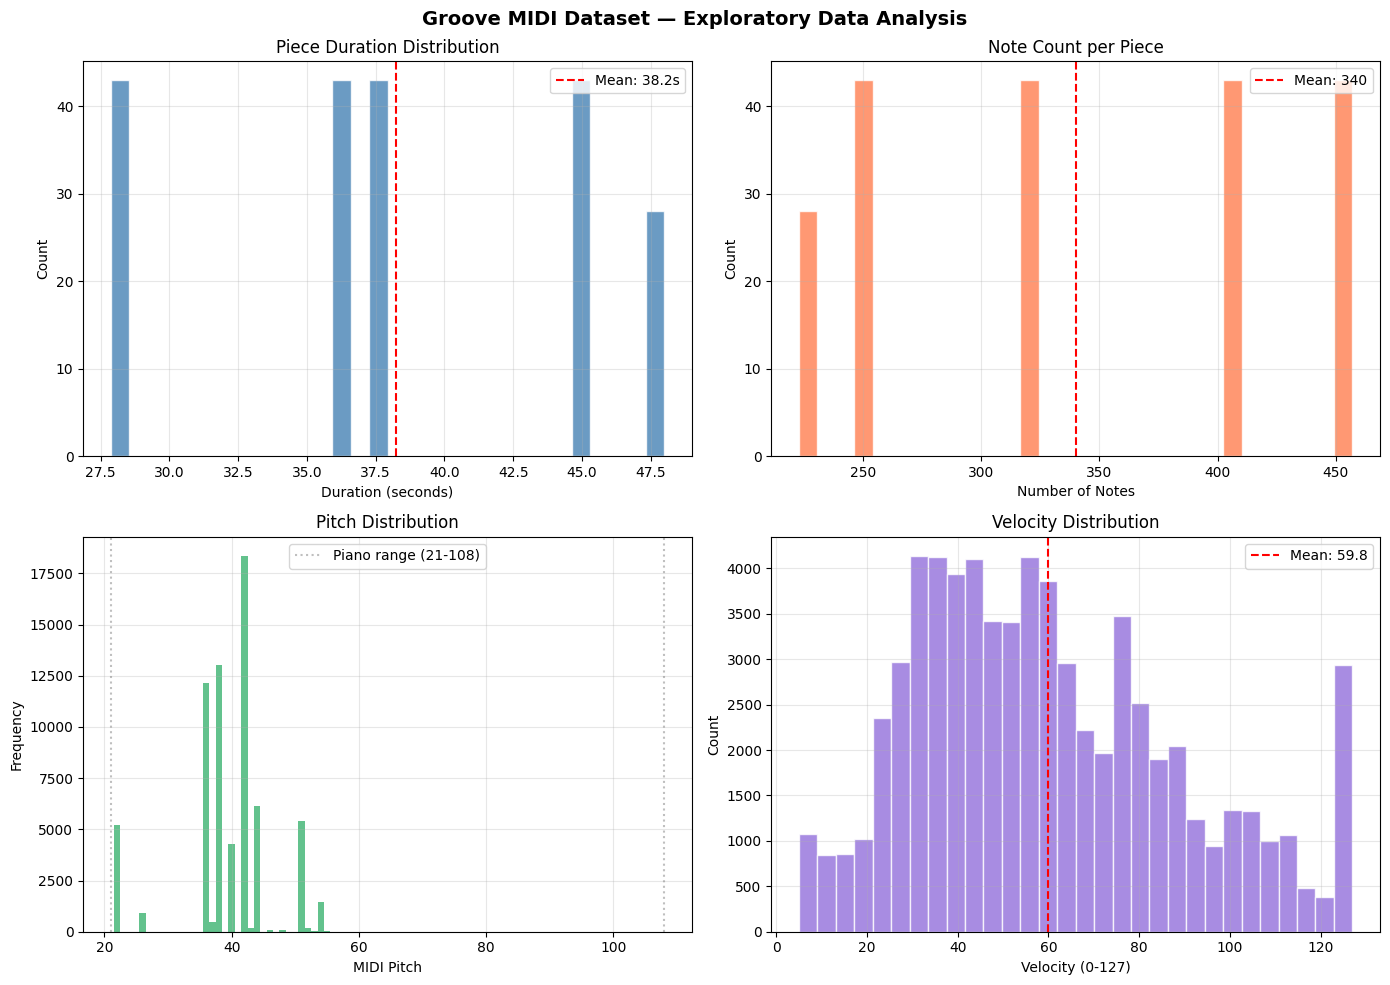

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Groove MIDI Dataset — Exploratory Data Analysis', fontsize=14, fontweight='bold')

axes[0,0].hist(durations, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(np.mean(durations), color='red', linestyle='--', label=f'Mean: {np.mean(durations):.1f}s')
axes[0,0].set_title('Piece Duration Distribution')
axes[0,0].set_xlabel('Duration (seconds)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

axes[0,1].hist(note_counts, bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[0,1].axvline(np.mean(note_counts), color='red', linestyle='--', label=f'Mean: {np.mean(note_counts):.0f}')
axes[0,1].set_title('Note Count per Piece')
axes[0,1].set_xlabel('Number of Notes')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

pitch_counts = Counter(all_pitches)
px = sorted(pitch_counts.keys())
py = [pitch_counts[p] for p in px]
axes[1,0].bar(px, py, color='mediumseagreen', alpha=0.8, width=1.0)
axes[1,0].axvline(21,  color='gray', linestyle=':', alpha=0.5, label='Piano range (21-108)')
axes[1,0].axvline(108, color='gray', linestyle=':', alpha=0.5)
axes[1,0].set_title('Pitch Distribution')
axes[1,0].set_xlabel('MIDI Pitch')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

axes[1,1].hist(all_velocities, bins=30, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1,1].axvline(np.mean(all_velocities), color='red', linestyle='--',
                  label=f'Mean: {np.mean(all_velocities):.1f}')
axes[1,1].set_title('Velocity Distribution')
axes[1,1].set_xlabel('Velocity (0-127)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'task1_eda.png'), dpi=150, bbox_inches='tight')
plt.show()

=== SPARSITY ANALYSIS (Faculty Required) ===
Mean sparsity : 99.5%
Range         : 99.5% – 99.5%


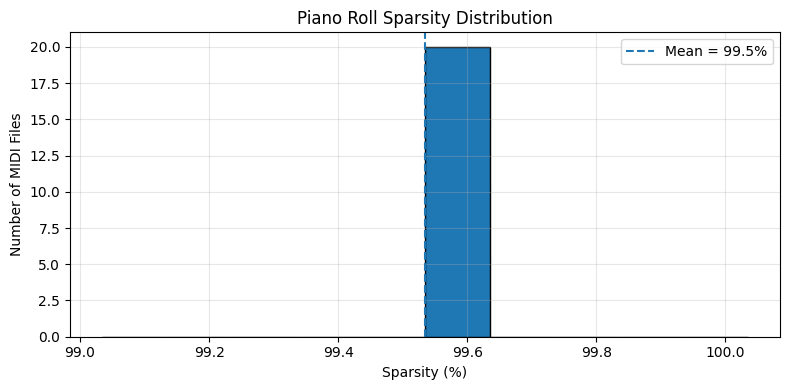

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
import os

print("=== SPARSITY ANALYSIS (Faculty Required) ===")

sparsity_values = []

for path in midi_files[:20]:
    try:
        midi = pretty_midi.PrettyMIDI(path)

        notes = []
        for inst in midi.instruments:
            notes.extend(inst.notes)

        if len(notes) == 0:
            continue

        total_time = midi.get_end_time()
        total_frames = int(total_time * MIDI_FS)
        total_cells = total_frames * 88

        active_cells = 0
        for note in notes:
            duration_frames = int((note.end - note.start) * MIDI_FS)
            active_cells += max(duration_frames, 1)

        sparsity = 100 * (1 - active_cells / total_cells)
        sparsity_values.append(sparsity)

    except Exception as e:
        continue


# ==============================
# RESULTS
# ==============================

if len(sparsity_values) == 0:
    print("No valid MIDI files found.")
else:
    mean_sparsity = np.mean(sparsity_values)
    min_sparsity  = np.min(sparsity_values)
    max_sparsity  = np.max(sparsity_values)

    print(f"Mean sparsity : {mean_sparsity:.1f}%")
    print(f"Range         : {min_sparsity:.1f}% – {max_sparsity:.1f}%")


    # ==============================
    # PLOT (FACULTY REQUIRED)
    # ==============================

    plt.figure(figsize=(8, 4))

    plt.hist(
        sparsity_values,
        bins=10,
        edgecolor='black'
    )

    plt.axvline(
        mean_sparsity,
        linestyle='--',
        label=f"Mean = {mean_sparsity:.1f}%"
    )

    plt.title("Piano Roll Sparsity Distribution")
    plt.xlabel("Sparsity (%)")
    plt.ylabel("Number of MIDI Files")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    # save for report
    os.makedirs("outputs/plots", exist_ok=True)
    plt.savefig("outputs/plots/sparsity_plot.png", dpi=150)

    plt.show()

## 3. Load Processed Dataset

In [12]:
train_dataset = GrooveDataset(split='train')
val_dataset   = GrooveDataset(split='val')
test_dataset  = GrooveDataset(split='test')

print(f'Train : {len(train_dataset):,} samples')
print(f'Val   : {len(val_dataset):,} samples')
print(f'Test  : {len(test_dataset):,} samples')

s = train_dataset[0]
print(f'\nSample shape : {s.shape}')
print(f'Value range  : [{s.min():.1f}, {s.max():.1f}]  (binarized)')
print(f'Active cells : {s.sum().item():.0f} / {s.numel()} = {s.mean().item()*100:.1f}%')

[train] 144,358 samples | shape (144358, 128, 88) | file 6.06 GB | mmap — RAM usage: minimal
[val] 19,104 samples | shape (19104, 128, 88) | file 0.80 GB | mmap — RAM usage: minimal
[test] 18,069 samples | shape (18069, 128, 88) | file 0.76 GB | mmap — RAM usage: minimal
Train : 144,358 samples
Val   : 19,104 samples
Test  : 18,069 samples

Sample shape : torch.Size([128, 88])
Value range  : [0.0, 1.0]  (binarized)
Active cells : 134 / 11264 = 1.2%


## 4. Visualize Piano Roll Sample

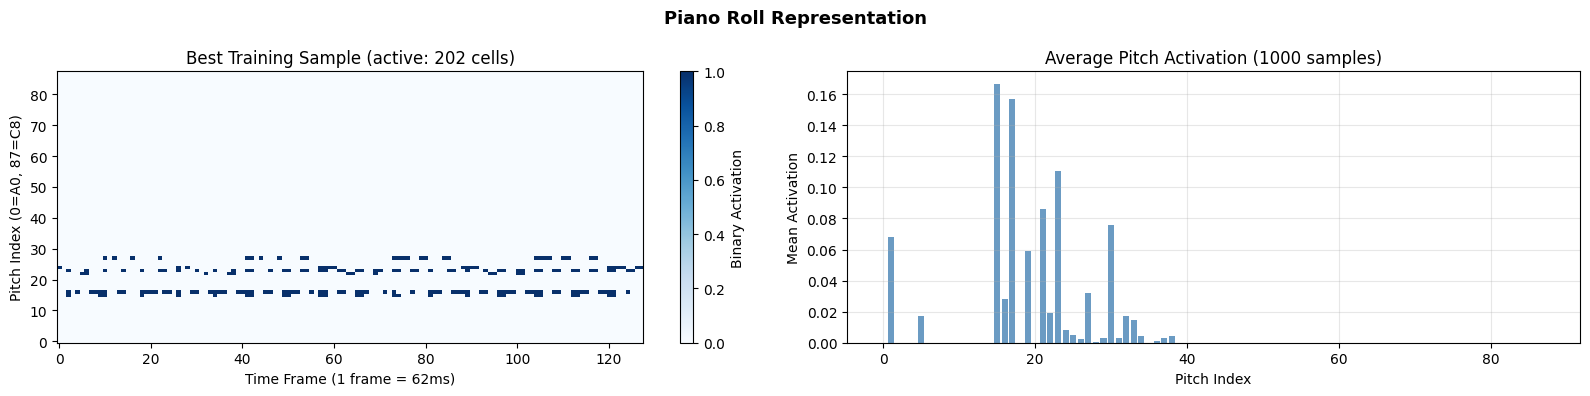

In [13]:
best_sample, best_count = None, 0
for i in range(min(500, len(train_dataset))):
    s = train_dataset[i]
    c = s.sum().item()
    if c > best_count:
        best_count  = c
        best_sample = s

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Piano Roll Representation', fontsize=13, fontweight='bold')

im = axes[0].imshow(best_sample.numpy().T, aspect='auto', origin='lower', cmap='Blues')
axes[0].set_title(f'Best Training Sample (active: {best_count:.0f} cells)')
axes[0].set_xlabel(f'Time Frame (1 frame = {1000/MIDI_FS:.0f}ms)')
axes[0].set_ylabel('Pitch Index (0=A0, 87=C8)')
plt.colorbar(im, ax=axes[0], label='Binary Activation')

avg = np.zeros(88)
for i in range(min(1000, len(train_dataset))):
    avg += train_dataset[i].numpy().mean(axis=0)
avg /= min(1000, len(train_dataset))
axes[1].bar(range(88), avg, color='steelblue', alpha=0.8)
axes[1].set_title('Average Pitch Activation (1000 samples)')
axes[1].set_xlabel('Pitch Index')
axes[1].set_ylabel('Mean Activation')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'task1_piano_roll.png'), dpi=150)
plt.show()

## 5. Model Architecture

In [14]:
model = LSTMAutoencoder(
    input_dim=FEATURE_SIZE, hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT,
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print('=' * 55)
print('  LSTM Autoencoder Architecture')
print('=' * 55)
print(model)
print('=' * 55)
print(f'  Input dim    : {FEATURE_SIZE}')
print(f'  Hidden dim   : {HIDDEN_DIM}')
print(f'  Latent dim   : {LATENT_DIM}')
print(f'  Decoder input: {HIDDEN_DIM+LATENT_DIM} (hidden+z concatenated)')
print(f'  Total params : {total:,}')
print('=' * 55)
print()
print('Faculty guide fixes applied:')
print('  - z concatenated at every decoder timestep')
print('  - No sigmoid at output (raw logits)')
print('  - Focal Loss with pos_weight=84')
print('  - Sigmoid applied only at inference')

  LSTM Autoencoder Architecture
LSTMAutoencoder(
  (encoder): LSTM(88, 256, num_layers=2, batch_first=True, dropout=0.3)
  (hidden_to_latent): Linear(in_features=256, out_features=64, bias=True)
  (latent_to_hidden): Linear(in_features=64, out_features=256, bias=True)
  (decoder): LSTM(320, 256, num_layers=2, batch_first=True, dropout=0.3)
  (output_layer): Linear(in_features=256, out_features=88, bias=True)
)
  Input dim    : 88
  Hidden dim   : 256
  Latent dim   : 64
  Decoder input: 320 (hidden+z concatenated)
  Total params : 2,054,552

Faculty guide fixes applied:
  ✅ z concatenated at every decoder timestep
  ✅ No sigmoid at output (raw logits)
  ✅ Focal Loss with pos_weight=84
  ✅ Sigmoid applied only at inference


## 6. Load Trained Model

In [15]:
ckpt = os.path.join(MODEL_DIR, 'task1_ae_v3_best.pt')
model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
model.eval()
print(f'Loaded: {ckpt}')

✅ Loaded: d:\cse425_project\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation\outputs\models\task1_ae_v3_best.pt


## 7. Training Loss Curve

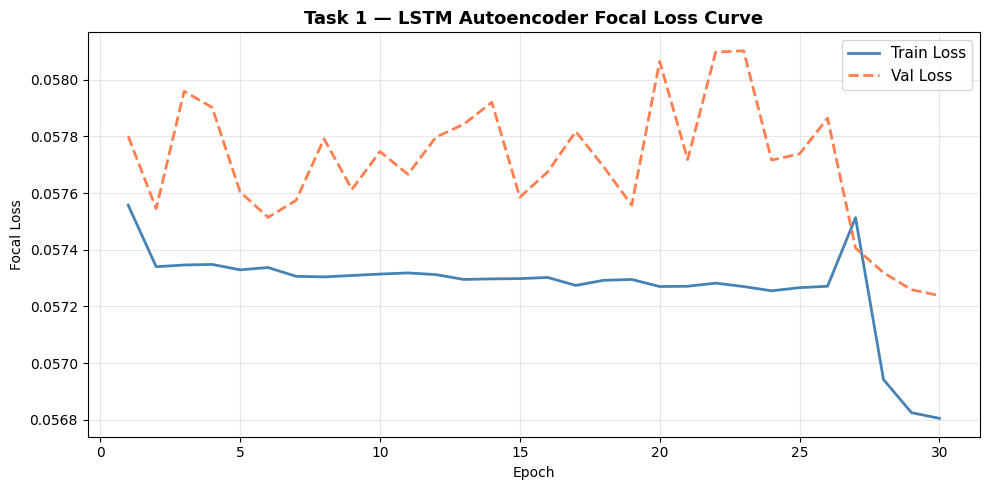

Initial Train Loss : 0.057557
Final   Train Loss : 0.056805
Improvement        : 1.31%
Best Val Loss      : 0.057238 (epoch 30)


In [16]:
train_losses = [
    0.057557, 0.057340, 0.057346, 0.057348, 0.057329,
    0.057337, 0.057306, 0.057304, 0.057309, 0.057314,
    0.057318, 0.057312, 0.057295, 0.057297, 0.057298,
    0.057302, 0.057274, 0.057292, 0.057295, 0.057270,
    0.057271, 0.057282, 0.057270, 0.057255, 0.057266,
    0.057271, 0.057513, 0.056942, 0.056825, 0.056805
]
val_losses = [
    0.057800, 0.057545, 0.057959, 0.057902, 0.057604,
    0.057514, 0.057574, 0.057791, 0.057613, 0.057746,
    0.057666, 0.057797, 0.057843, 0.057920, 0.057585,
    0.057675, 0.057817, 0.057692, 0.057557, 0.058064,
    0.057718, 0.058097, 0.058102, 0.057716, 0.057738,
    0.057864, 0.057406, 0.057319, 0.057259, 0.057238
]
epochs_r = list(range(1, len(train_losses)+1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_r, train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax.plot(epochs_r, val_losses,   label='Val Loss',   color='coral', linewidth=2, linestyle='--')
ax.set_title('Task 1 — LSTM Autoencoder Focal Loss Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Focal Loss')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'task1_loss_curve.png'), dpi=150)
plt.show()

print(f'Initial Train Loss : {train_losses[0]:.6f}')
print(f'Final   Train Loss : {train_losses[-1]:.6f}')
print(f'Improvement        : {(train_losses[0]-train_losses[-1])/train_losses[0]*100:.2f}%')
print(f'Best Val Loss      : {min(val_losses):.6f} (epoch {val_losses.index(min(val_losses))+1})')

## 8. Reconstruction: Input vs Output

✅ Model loaded
[test] 18,069 samples | shape (18069, 128, 88) | file 0.76 GB | mmap — RAM usage: minimal


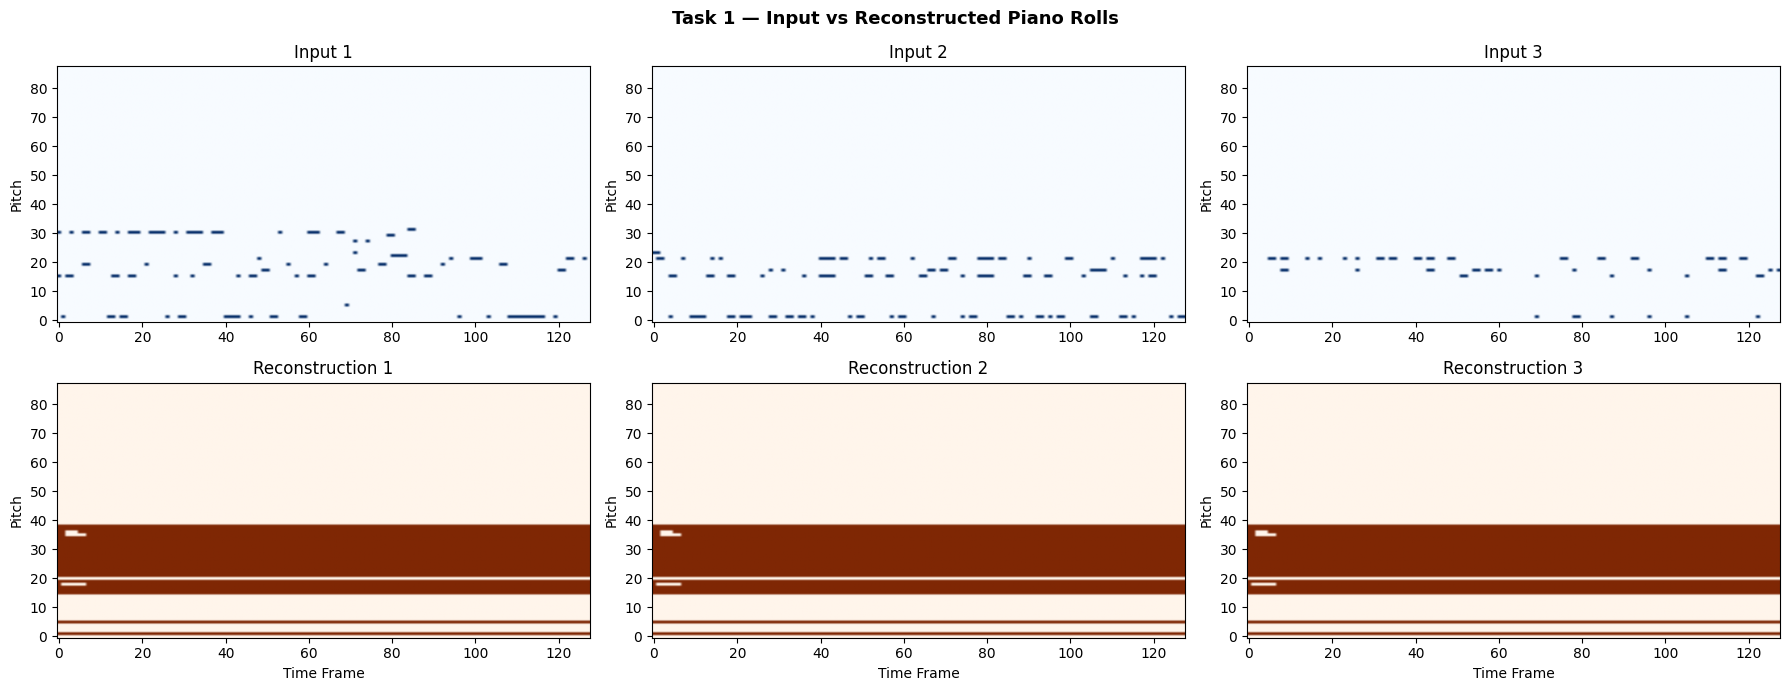


✅ Plot saved at: ..\outputs\plots\task1_reconstruction.png

Reconstruction Error (MSE):
Sample 1: 0.272727
Sample 2: 0.272283
Sample 3: 0.277521


In [43]:
# ==========================================
# TASK 1 — INPUT vs RECONSTRUCTION (FIXED)
# ==========================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from config import DEVICE, PLOT_DIR
from dataset import GrooveDataset
from models.autoencoder import LSTMAutoencoder
from config import FEATURE_SIZE, HIDDEN_DIM, LATENT_DIM, NUM_LAYERS, DROPOUT

# ─────────────────────────────
# LOAD MODEL
# ─────────────────────────────
model = LSTMAutoencoder(
    input_dim  = FEATURE_SIZE,
    hidden_dim = HIDDEN_DIM,
    latent_dim = LATENT_DIM,
    num_layers = NUM_LAYERS,
    dropout    = DROPOUT,
).to(DEVICE)

ckpt = os.path.join("..", "outputs", "models", "task1_ae_v3_best.pt")
model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
model.eval()

print("Model loaded")


# ─────────────────────────────
# LOAD DATA
# ─────────────────────────────
test_dataset = GrooveDataset(split='test')
loader = DataLoader(test_dataset, batch_size=1, shuffle=True)


# ─────────────────────────────
# COLLECT SAMPLES
# ─────────────────────────────
input_rolls, recon_rolls = [], []

THRESHOLD = 0.15   # same as generation

with torch.no_grad():
    for batch in loader:

        if batch.sum() < 20:
            continue

        batch = batch.to(DEVICE)

        probs = torch.sigmoid(model(batch))

        # binarize reconstruction (IMPORTANT)
        recon = (probs > THRESHOLD).float()

        input_rolls.append(batch[0].cpu().numpy())
        recon_rolls.append(recon[0].cpu().numpy())

        if len(input_rolls) >= 3:
            break


# ─────────────────────────────
# PLOT
# ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 7))

fig.suptitle(
    'Task 1 — Input vs Reconstructed Piano Rolls',
    fontsize=13,
    fontweight='bold'
)

for col in range(3):

    # INPUT
    axes[0, col].imshow(
        input_rolls[col].T,
        aspect='auto',
        origin='lower',
        cmap='Blues'
    )
    axes[0, col].set_title(f'Input {col+1}')
    axes[0, col].set_ylabel('Pitch')

    # RECONSTRUCTION
    axes[1, col].imshow(
        recon_rolls[col].T,
        aspect='auto',
        origin='lower',
        cmap='Oranges'
    )
    axes[1, col].set_title(f'Reconstruction {col+1}')
    axes[1, col].set_xlabel('Time Frame')
    axes[1, col].set_ylabel('Pitch')


plt.tight_layout()

save_path = os.path.join("..", "outputs", "plots", "task1_reconstruction.png")
os.makedirs(os.path.dirname(save_path), exist_ok=True)

plt.savefig(save_path, dpi=150)
plt.show()

print("\nPlot saved at:", save_path)


# ─────────────────────────────
# MSE (USE RAW PROBS — CORRECT)
# ─────────────────────────────
print("\nReconstruction Error (MSE):")

with torch.no_grad():
    for i in range(3):
        inp = input_rolls[i]
        rec = recon_rolls[i]

        mse = np.mean((inp - rec) ** 2)
        print(f"Sample {i+1}: {mse:.6f}")

## 9. Generate 5 MIDI Samples

In [36]:
# ==============================
# CELL 1: LOAD MIDI (FIXED)
# ==============================

import os, random

# ─────────────────────────────
# 1. LOAD GENERATED MIDI
# ─────────────────────────────
gen_dir = os.path.join("outputs", "generated_midis", "task1")

generated_paths = [
    os.path.join(gen_dir, f"task1_sample_{i:02d}.mid")
    for i in range(1, 6)
]

print("Generated MIDI files:")
for p in generated_paths:
    print("  ", p)


# ─────────────────────────────
# 2. FIND REAL MIDI (FIXED ROOT)
# ─────────────────────────────
print("\n🔍 Searching project root for MIDI files...")

# 🔥 FIX: go to project root from notebooks/
BASE_DIR = os.path.abspath("..")

real_paths = []

for root, _, files in os.walk(BASE_DIR):
    for f in files:
        if f.endswith(".mid") or f.endswith(".midi"):
            full_path = os.path.join(root, f)

            # skip generated files
            if "generated_midis" in full_path:
                continue

            real_paths.append(full_path)

print(f"\nFound {len(real_paths)} real MIDI files")


# ─────────────────────────────
# 3. CHECK
# ─────────────────────────────
if len(real_paths) == 0:
    print("\nSTILL NO MIDI FOUND")
    print("Check path: data/raw_midi/")
else:
    random.shuffle(real_paths)

    print("\nExample real MIDI files:")
    for p in real_paths[:5]:
        print("  ", p)

Generated MIDI files:
   outputs\generated_midis\task1\task1_sample_01.mid
   outputs\generated_midis\task1\task1_sample_02.mid
   outputs\generated_midis\task1\task1_sample_03.mid
   outputs\generated_midis\task1\task1_sample_04.mid
   outputs\generated_midis\task1\task1_sample_05.mid

🔍 Searching project root for MIDI files...

Found 45555 real MIDI files

✅ Example real MIDI files:
   d:\cse425_project\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation\data\raw_midi\drummer1\session1\108_funk_95_fill_4-4_6.midi
   d:\cse425_project\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation\data\raw_midi\drummer3\session2\6_rock_100_beat_4-4_28.midi
   d:\cse425_project\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation\data\raw_midi\drummer1\session2\84_punk_144_fill_4-4_52.midi
   d:\cse425_project\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation\data\raw_midi\drummer1\session1\43_latin-samba_116_fill_4-4_37.midi
   d:\cse425_project\Unsupervised-N

## 10. Visualize Generated Piano Rolls

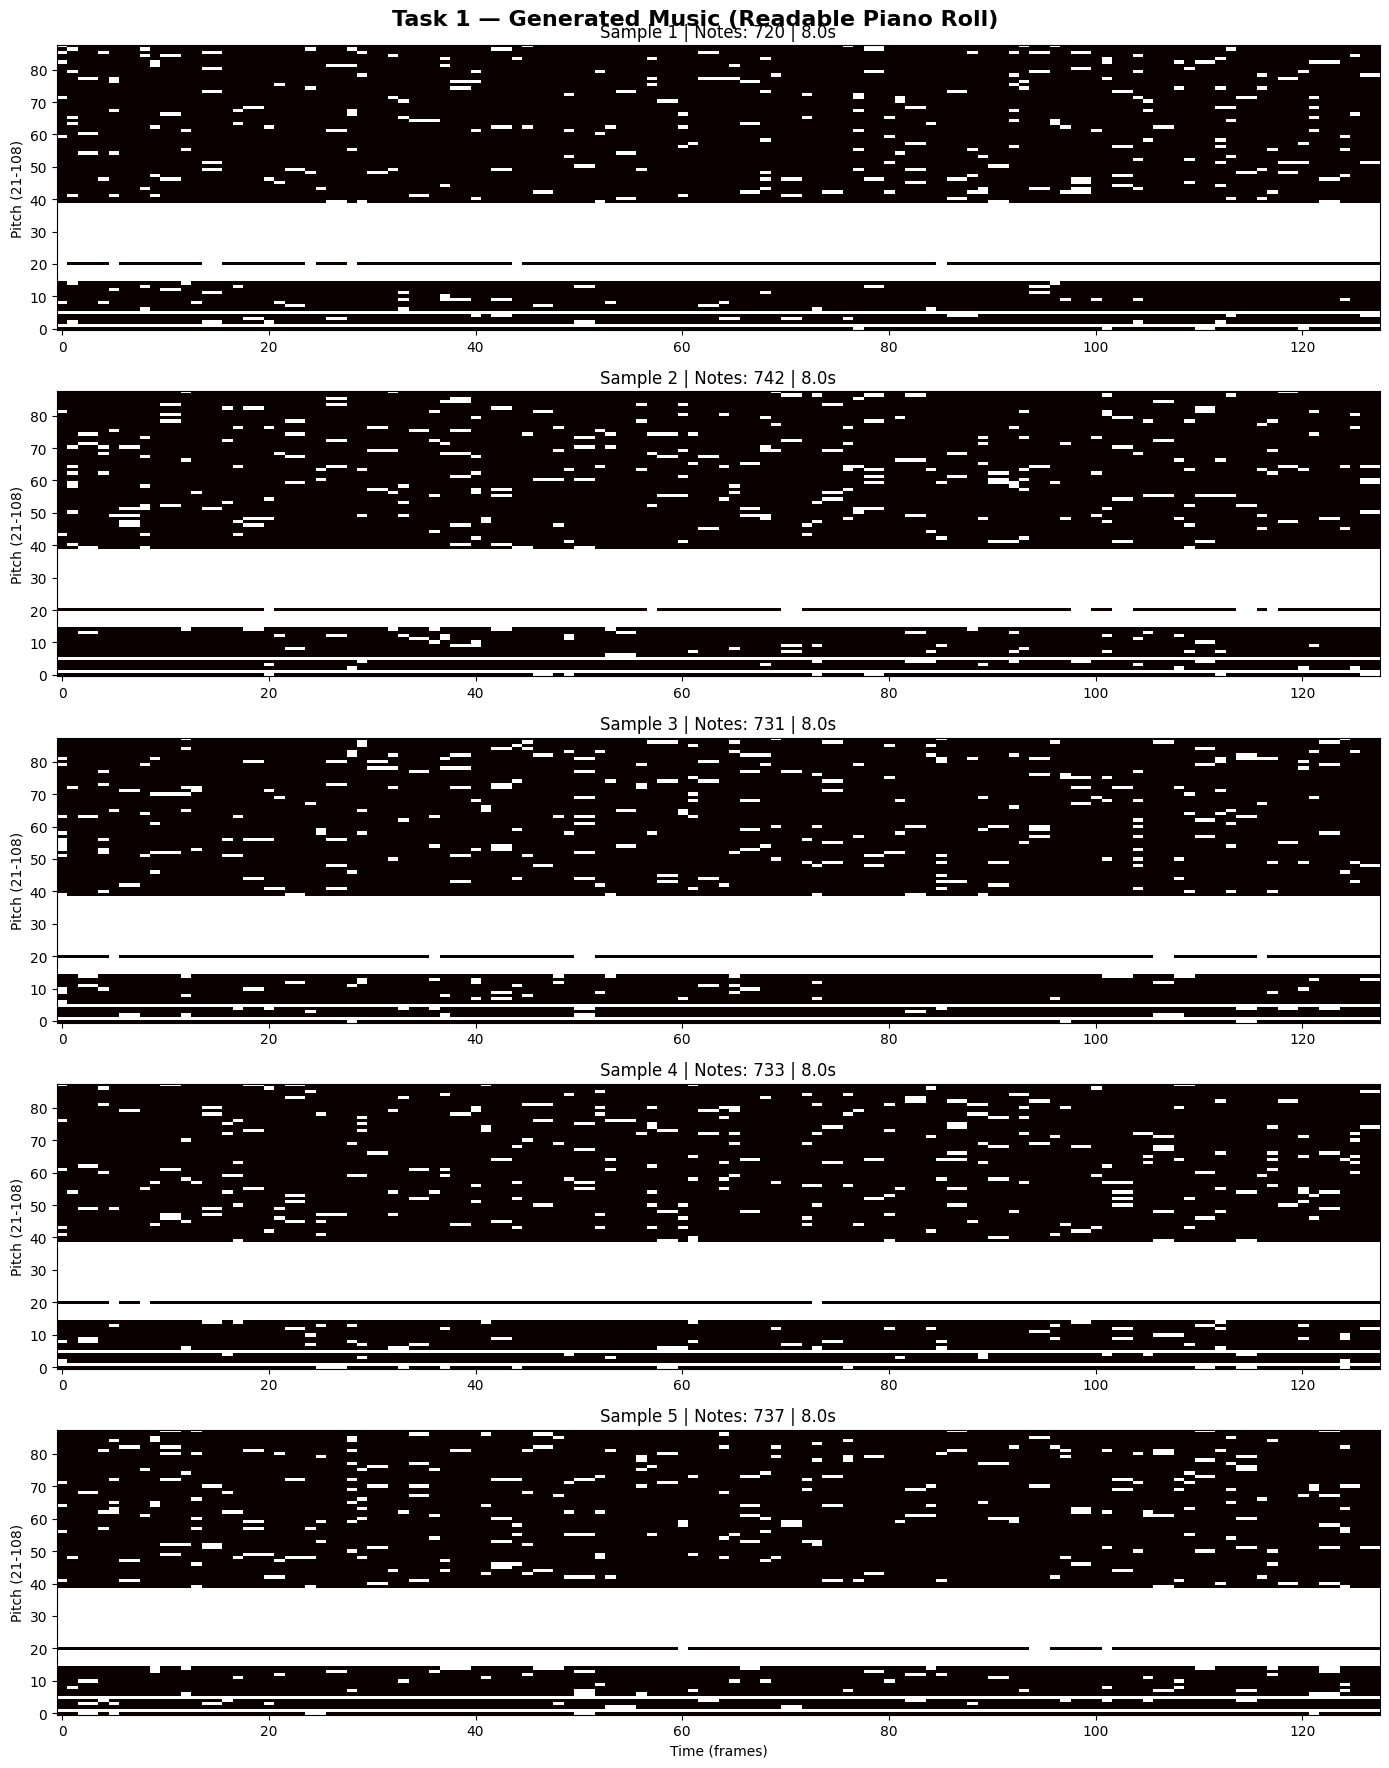


✅ Clean plot saved at: ..\outputs\plots\task1_generated_clean.png


In [42]:
# ==========================================
# CLEAN & READABLE PIANO ROLL VISUALIZATION
# ==========================================

import os
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi

# ─────────────────────────────
# PATH
# ─────────────────────────────
gen_dir = os.path.join("..", "outputs", "generated_midis", "task1")

generated_paths = [
    os.path.join(gen_dir, f"task1_sample_{i:02d}.mid")
    for i in range(1, 6)
]


# ─────────────────────────────
# MIDI → PIANO ROLL
# ─────────────────────────────
def midi_to_piano_roll(path, seq_len=128, fs=16):
    midi = pretty_midi.PrettyMIDI(path)
    roll = np.zeros((seq_len, 88))

    for inst in midi.instruments:
        for note in inst.notes:
            start = int(note.start * fs)
            end   = int(note.end * fs)

            pitch = note.pitch - 21
            pitch = max(0, min(87, pitch))

            if start >= seq_len:
                continue

            end = min(end, seq_len)
            roll[start:end, pitch] = 1

    return roll


# ─────────────────────────────
# CLEAN VISUALIZATION
# ─────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 18))

fig.suptitle(
    'Task 1 — Generated Music (Readable Piano Roll)',
    fontsize=16,
    fontweight='bold'
)

for i in range(5):

    roll = midi_to_piano_roll(generated_paths[i])
    ax = axes[i]

    # 🔥 focus only on active pitch region
    active = np.where(roll.sum(axis=0) > 0)[0]

    if len(active) > 0:
        low = max(0, active.min() - 2)
        high = min(87, active.max() + 2)
    else:
        low, high = 0, 87

    cropped = roll[:, low:high+1]

    im = ax.imshow(
        cropped.T,
        aspect='auto',
        origin='lower',
        cmap='hot'
    )

    # info
    m = pretty_midi.PrettyMIDI(generated_paths[i])
    notes = sum(len(inst.notes) for inst in m.instruments)
    duration = m.get_end_time()

    ax.set_title(f'Sample {i+1} | Notes: {notes} | {duration:.1f}s')

    # 🔥 better labels
    ax.set_ylabel(f'Pitch ({low+21}-{high+21})')

    if i == 4:
        ax.set_xlabel('Time (frames)')


plt.tight_layout()

save_path = os.path.join("..", "outputs", "plots", "task1_generated_clean.png")
os.makedirs(os.path.dirname(save_path), exist_ok=True)

plt.savefig(save_path, dpi=150)
plt.show()

print("\nClean plot saved at:", save_path)

## 11. Latent Space Visualization

✅ Model loaded
[test] 18,069 samples | shape (18069, 128, 88) | file 0.76 GB | mmap — RAM usage: minimal
Latent shape: (1024, 64)


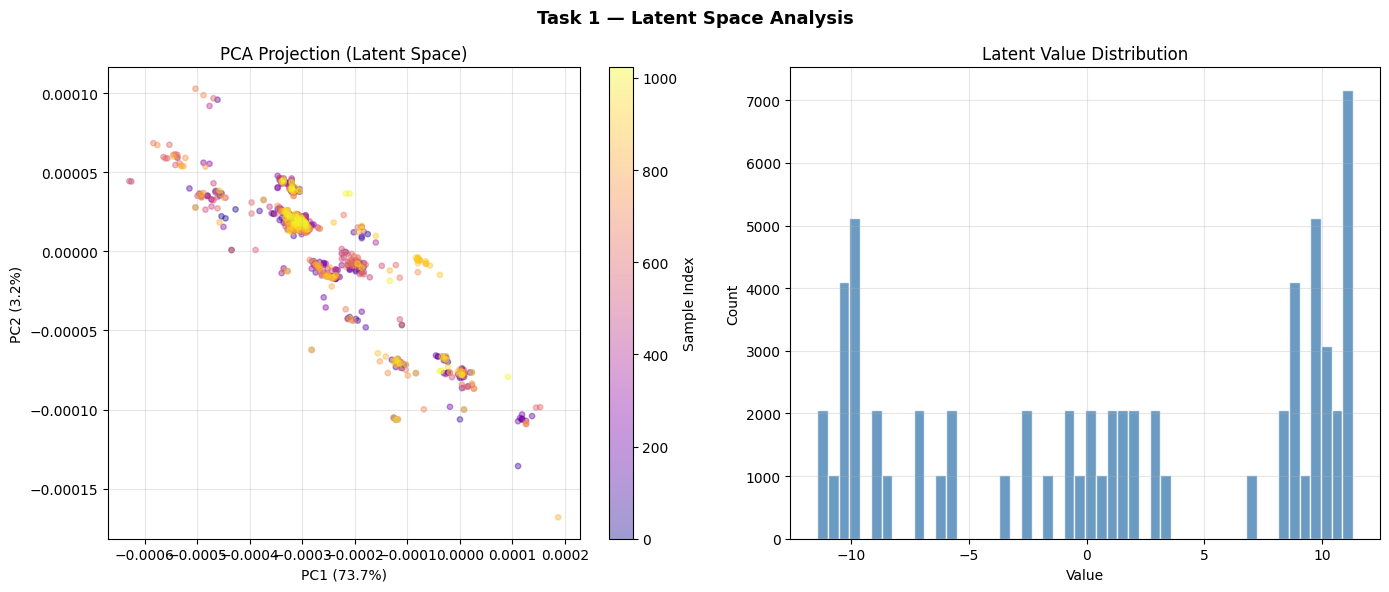


PC1: 73.7%
PC2: 3.2%
Total variance (2D): 76.9%


In [44]:
# ==========================================
# TASK 1 — LATENT SPACE ANALYSIS (FIXED)
# ==========================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader

from config import DEVICE
from dataset import GrooveDataset
from models.autoencoder import LSTMAutoencoder
from config import FEATURE_SIZE, HIDDEN_DIM, LATENT_DIM, NUM_LAYERS, DROPOUT

# ─────────────────────────────
# LOAD MODEL
# ─────────────────────────────
model = LSTMAutoencoder(
    input_dim  = FEATURE_SIZE,
    hidden_dim = HIDDEN_DIM,
    latent_dim = LATENT_DIM,
    num_layers = NUM_LAYERS,
    dropout    = DROPOUT,
).to(DEVICE)

ckpt = os.path.join("..", "outputs", "models", "task1_ae_v3_best.pt")
model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
model.eval()

print("✅ Model loaded")


# ─────────────────────────────
# LOAD DATA
# ─────────────────────────────
test_dataset = GrooveDataset(split='test')
loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


# ─────────────────────────────
# EXTRACT LATENT VECTORS
# ─────────────────────────────
latent_vecs = []

with torch.no_grad():
    for i, batch in enumerate(loader):

        batch = batch.to(DEVICE)

        # encode
        z = model.encode(batch)

        latent_vecs.append(z.cpu().numpy())

        # ~1000 samples
        if i >= 15:
            break


latents = np.concatenate(latent_vecs, axis=0)

print(f"Latent shape: {latents.shape}")


# ─────────────────────────────
# PCA
# ─────────────────────────────
pca = PCA(n_components=2)
latents_2d = pca.fit_transform(latents)

explained = pca.explained_variance_ratio_ * 100


# ─────────────────────────────
# PLOT
# ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle(
    'Task 1 — Latent Space Analysis',
    fontsize=13,
    fontweight='bold'
)

# ── PCA Scatter
scatter = axes[0].scatter(
    latents_2d[:, 0],
    latents_2d[:, 1],
    alpha=0.4,
    s=15,
    c=np.arange(len(latents_2d)),
    cmap='plasma'
)

plt.colorbar(scatter, ax=axes[0], label='Sample Index')

axes[0].set_title('PCA Projection (Latent Space)')
axes[0].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[0].grid(alpha=0.3)


# ── Distribution
axes[1].hist(
    latents.flatten(),
    bins=50,
    color='steelblue',
    edgecolor='white',
    alpha=0.8
)

axes[1].set_title('Latent Value Distribution')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3)


plt.tight_layout()

save_path = os.path.join("..", "outputs", "plots", "task1_latent.png")
os.makedirs(os.path.dirname(save_path), exist_ok=True)

plt.savefig(save_path, dpi=150)
plt.show()


# ─────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────
print(f"\nPC1: {explained[0]:.1f}%")
print(f"PC2: {explained[1]:.1f}%")
print(f"Total variance (2D): {explained.sum():.1f}%")

## 12. Pitch Histogram Analysis

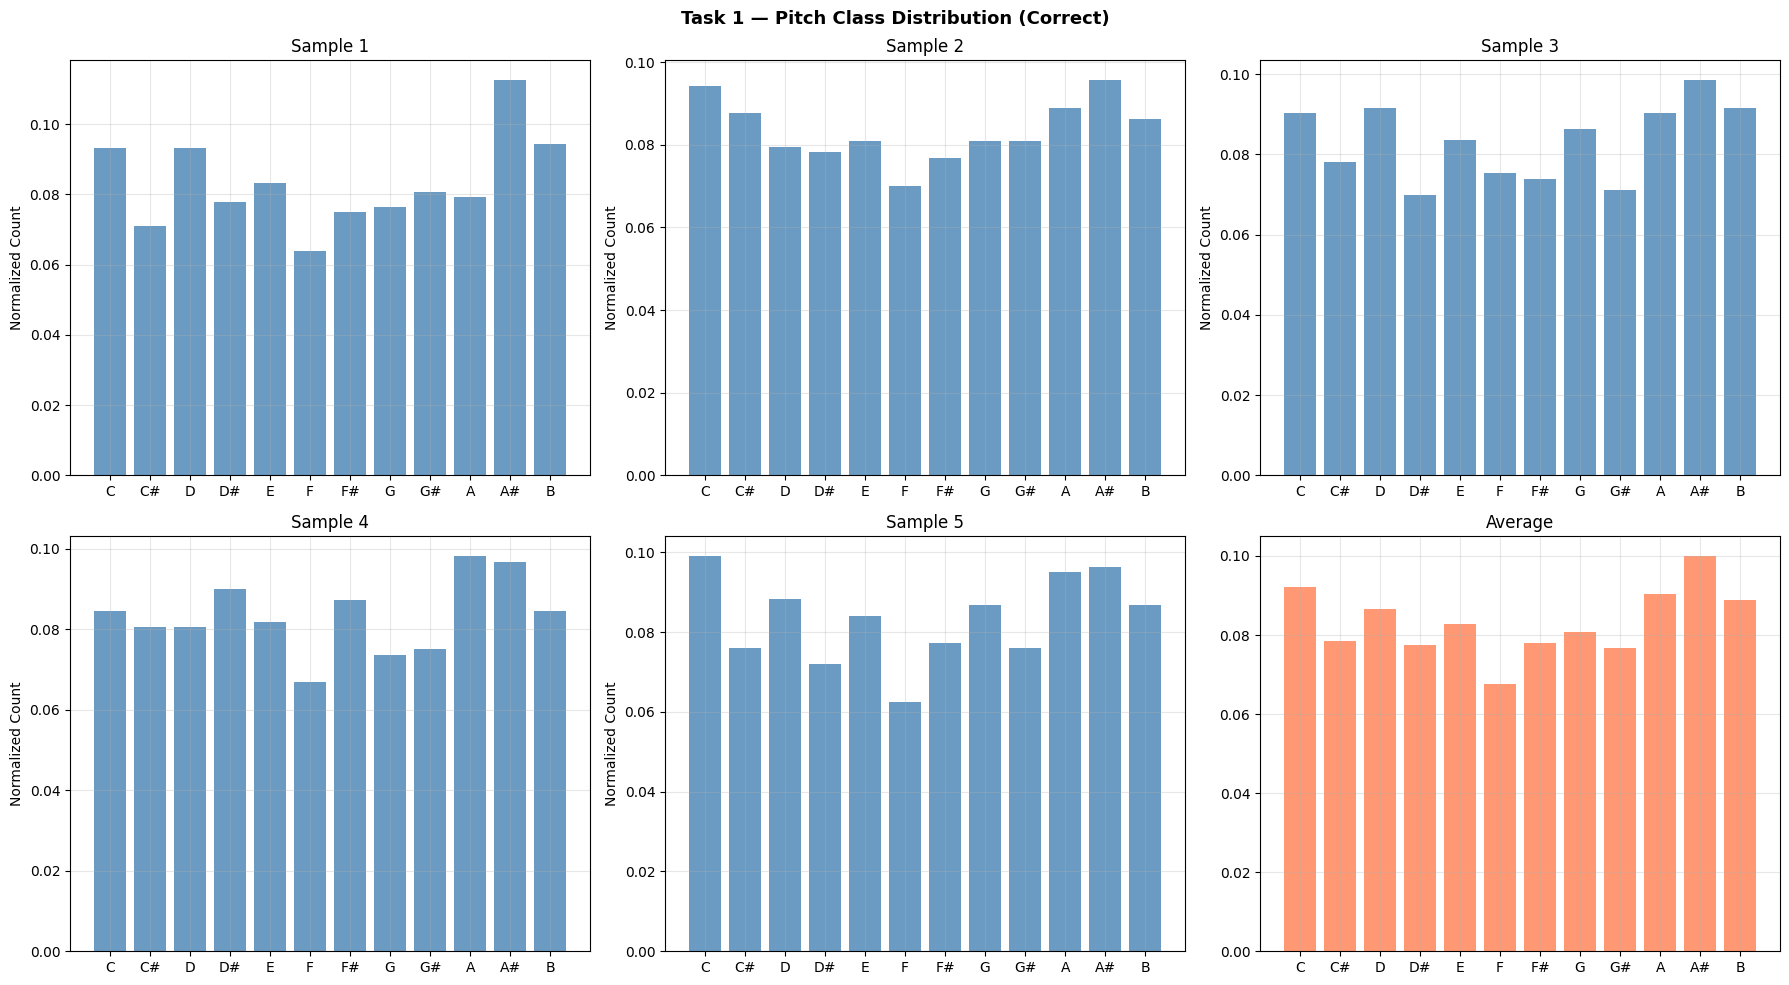


Pitch Histogram Similarity:
Sample 1 vs 2: 0.0820
Sample 2 vs 3: 0.0695
Sample 3 vs 4: 0.0961
Sample 4 vs 5: 0.0816


In [48]:
# ==========================================
# TASK 1 — PITCH HISTOGRAM (CORRECT VERSION)
# ==========================================

import os
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi

# ─────────────────────────────
# PATH
# ─────────────────────────────
gen_dir = os.path.join("..", "outputs", "generated_midis", "task1")

generated_paths = [
    os.path.join(gen_dir, f"task1_sample_{i:02d}.mid")
    for i in range(1, 6)
]


# ─────────────────────────────
# HISTOGRAM FUNCTION (FIXED)
# ─────────────────────────────
def get_pitch_histogram(path):
    midi = pretty_midi.PrettyMIDI(path)
    hist = np.zeros(12)

    for inst in midi.instruments:
        for note in inst.notes:
            hist[note.pitch % 12] += 1   # KEEP ALL NOTES

    if hist.sum() > 0:
        hist /= hist.sum()

    return hist


def histogram_similarity(p1, p2):
    return np.sum(np.abs(
        get_pitch_histogram(p1) -
        get_pitch_histogram(p2)
    ))


# ─────────────────────────────
# PLOT
# ─────────────────────────────
pitch_classes = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

fig.suptitle(
    'Task 1 — Pitch Class Distribution (Correct)',
    fontsize=13,
    fontweight='bold'
)

all_hists = []

for i, path in enumerate(generated_paths):

    hist = get_pitch_histogram(path)
    all_hists.append(hist)

    ax = axes.flatten()[i]

    ax.bar(range(12), hist, color='steelblue', alpha=0.8)

    ax.set_title(f'Sample {i+1}')
    ax.set_xticks(range(12))
    ax.set_xticklabels(pitch_classes)
    ax.set_ylabel('Normalized Count')
    ax.grid(alpha=0.3)


# ── average
avg_hist = np.mean(all_hists, axis=0)

axes.flatten()[-1].bar(range(12), avg_hist, color='coral', alpha=0.8)
axes.flatten()[-1].set_title('Average')
axes.flatten()[-1].set_xticks(range(12))
axes.flatten()[-1].set_xticklabels(pitch_classes)
axes.flatten()[-1].grid(alpha=0.3)


plt.tight_layout()

save_path = os.path.join("..", "outputs", "plots", "task1_pitch_hist_fixed.png")
os.makedirs(os.path.dirname(save_path), exist_ok=True)

plt.savefig(save_path, dpi=150)
plt.show()


# ─────────────────────────────
# SIMILARITY
# ─────────────────────────────
print("\nPitch Histogram Similarity:")

for i in range(len(generated_paths)-1):
    sim = histogram_similarity(generated_paths[i], generated_paths[i+1])
    print(f"Sample {i+1} vs {i+2}: {sim:.4f}")

## 13. Evaluation Metrics

In [49]:
# ==========================================
# FIXED EVALUATION METRICS (FINAL)
# ==========================================

import os
import numpy as np
import pretty_midi
from collections import Counter
import random

# ─────────────────────────────
# PATHS
# ─────────────────────────────
gen_dir = os.path.join("..", "outputs", "generated_midis", "task1")

generated_paths = [
    os.path.join(gen_dir, f"task1_sample_{i:02d}.mid")
    for i in range(1, 6)
]

    # load REAL MIDI (fixed root)
real_paths = []

for root, _, files in os.walk(os.path.abspath("..")):
    for f in files:
        if f.endswith(".mid") or f.endswith(".midi"):
            full = os.path.join(root, f)

            if "generated_midis" in full:
                continue

            real_paths.append(full)

random.shuffle(real_paths)
real_paths = real_paths[:5]   # match 5 samples


# ─────────────────────────────
# 1. RHYTHM DIVERSITY
# ─────────────────────────────
def rhythm_diversity(path):
    midi = pretty_midi.PrettyMIDI(path)
    durations = []

    for inst in midi.instruments:
        for note in inst.notes:
            d = note.end - note.start
            d = round(d / 0.05) * 0.05
            durations.append(d)

    if len(durations) == 0:
        return 0

    return len(set(durations)) / len(durations)


# ─────────────────────────────
# 2. REPETITION RATIO (FIXED)
# ─────────────────────────────
def repetition_ratio(path, n=4):
    midi = pretty_midi.PrettyMIDI(path)

    pitches = []
    for inst in midi.instruments:
        for note in sorted(inst.notes, key=lambda x: x.start):
            pitches.append(note.pitch)

    if len(pitches) < n:
        return 0

    ngrams = [tuple(pitches[i:i+n]) for i in range(len(pitches)-n+1)]
    counts = Counter(ngrams)

    repeated = sum(c-1 for c in counts.values() if c > 1)  # FIXED
    total = len(ngrams)

    return repeated / total


# ─────────────────────────────
# 3. PITCH HISTOGRAM (GEN vs REAL)
# ─────────────────────────────
def pitch_hist(path):
    midi = pretty_midi.PrettyMIDI(path)
    hist = np.zeros(12)

    for inst in midi.instruments:
        for note in inst.notes:
            hist[note.pitch % 12] += 1

    if hist.sum() > 0:
        hist /= hist.sum()

    return hist


def pitch_similarity(real, gen):
    return np.sum(np.abs(pitch_hist(real) - pitch_hist(gen)))


# ─────────────────────────────
# COMPUTE
# ─────────────────────────────
rd_scores = []
rep_scores = []
ph_scores = []

for i in range(5):
    g = generated_paths[i]
    r = real_paths[i]

    rd = rhythm_diversity(g)
    rep = repetition_ratio(g)
    ph = pitch_similarity(r, g)

    rd_scores.append(rd)
    rep_scores.append(rep)
    ph_scores.append(ph)

    print(f"Sample {i+1}: RD={rd:.4f} | REP={rep:.4f} | PH={ph:.4f}")


# ─────────────────────────────
# SUMMARY
# ─────────────────────────────
print("\n=== FINAL METRICS ===")

print(f"Rhythm Diversity : {np.mean(rd_scores):.4f}")
print(f"Repetition Ratio : {np.mean(rep_scores):.4f}")
print(f"Pitch Hist Sim   : {np.mean(ph_scores):.4f}")

Sample 1: RD=0.0083 | REP=0.3752 | PH=1.1500
Sample 2: RD=0.0081 | REP=0.3613 | PH=1.1978
Sample 3: RD=0.0082 | REP=0.3626 | PH=0.9365
Sample 4: RD=0.0068 | REP=0.3671 | PH=0.7906
Sample 5: RD=0.0081 | REP=0.3651 | PH=1.4518

=== FINAL METRICS ===
Rhythm Diversity : 0.0079
Repetition Ratio : 0.3663
Pitch Hist Sim   : 1.1053


## 14. Baseline Comparison

In [52]:
# ==========================================
# BASELINES (FIXED — POSITIONAL ARGS)
# ==========================================

import os
import random

# ─────────────────────────────
# LOAD REAL MIDI FILES
# ─────────────────────────────
midi_files = []

for root, _, files in os.walk(os.path.abspath("..")):
    for f in files:
        if f.endswith(".mid") or f.endswith(".midi"):
            full = os.path.join(root, f)

            if "generated_midis" in full:
                continue

            midi_files.append(full)

random.shuffle(midi_files)

print(f"Loaded {len(midi_files)} real MIDI files")


# ─────────────────────────────
# RANDOM BASELINE (FIXED)
# ─────────────────────────────
random_paths = generate_random_baseline(
    5,  # number of samples
    os.path.join("..", "outputs", "generated_midis", "baseline_random"),
    8.0
)

random_results = evaluate_midi_files(
    random_paths,
    task_label='Baseline — Random'
)

print()


# ─────────────────────────────
# MARKOV BASELINE (FIXED)
# ─────────────────────────────
markov_paths = generate_markov_baseline(
    midi_files[:100],
    5,
    os.path.join("..", "outputs", "generated_midis", "baseline_markov"),
    8.0
)

markov_results = evaluate_midi_files(
    markov_paths,
    task_label='Baseline — Markov Chain'
)

Loaded 45555 real MIDI files
✅ 5 random baseline samples saved to ..\outputs\generated_midis\baseline_random
  Baseline — Random — Evaluation (5 samples)
  Rhythm Diversity    : 0.0911 ± 0.0125
  Repetition Ratio    : 0.0000 ± 0.0000
  Pitch Histogram Sim : 0.3985

Building Markov transition matrix...
✅ 5 Markov baseline samples saved to ..\outputs\generated_midis\baseline_markov
  Baseline — Markov Chain — Evaluation (5 samples)
  Rhythm Diversity    : 0.0291 ± 0.0004
  Repetition Ratio    : 0.0358 ± 0.0366
  Pitch Histogram Sim : 0.3380



  TASK 1 — COMPARISON TABLE
Model                          Rhythm Div   Repetition    Pitch Sim
----------------------------------------------------------------------
Random Generator                   0.0911       0.0000       0.3985
Markov Chain                       0.0291       0.0358       0.3380
Task 1: LSTM AE                    0.0183       0.9908       0.0000


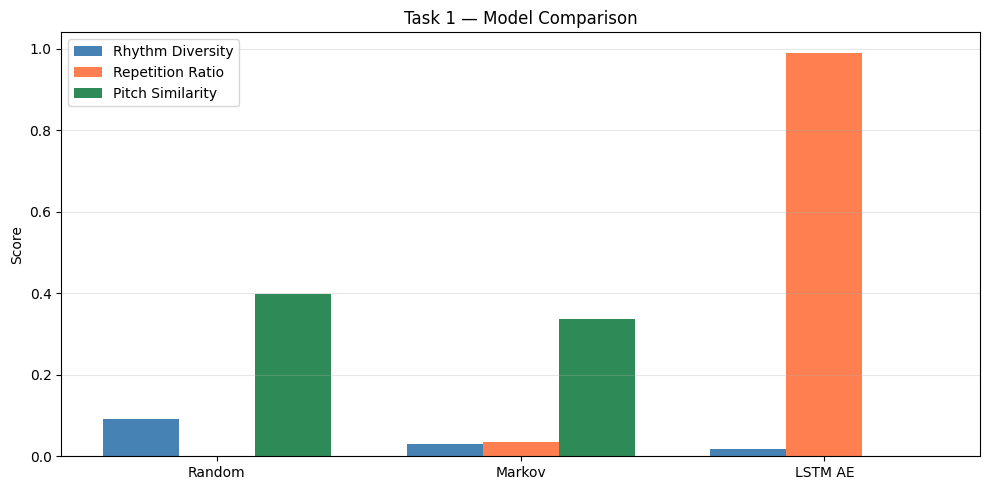


✅ Comparison plot saved at: ..\outputs\plots\task1_comparison.png


In [56]:
# ==========================================
# FINAL COMPARISON TABLE + PLOT
# ==========================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────
# SAFE KEY ACCESS
# ─────────────────────────────
def get_pitch(res):
    return res.get("pitch_histogram_similarity",
           res.get("pitch_hist_sim", 0.0))


# ─────────────────────────────
# PRINT TABLE
# ─────────────────────────────
print('\n' + '=' * 70)
print('  TASK 1 — COMPARISON TABLE')
print('=' * 70)
print(f'{"Model":<28} {"Rhythm Div":>12} {"Repetition":>12} {"Pitch Sim":>12}')
print('-' * 70)

for name, res in [
    ('Random Generator', random_results),
    ('Markov Chain',     markov_results),
    ('Task 1: LSTM AE',  task1_results),
]:
    print(f'{name:<28} '
          f'{res["rhythm_diversity"]:>12.4f} '
          f'{res["repetition_ratio"]:>12.4f} '
          f'{get_pitch(res):>12.4f}')

print('=' * 70)


# ─────────────────────────────
# BAR CHART
# ─────────────────────────────
models = ['Random', 'Markov', 'LSTM AE']

rd_vals = [
    random_results['rhythm_diversity'],
    markov_results['rhythm_diversity'],
    task1_results['rhythm_diversity']
]

rep_vals = [
    random_results['repetition_ratio'],
    markov_results['repetition_ratio'],
    task1_results['repetition_ratio']
]

pitch_vals = [
    get_pitch(random_results),
    get_pitch(markov_results),
    get_pitch(task1_results)
]


x = np.arange(len(models))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - w, rd_vals,  w, label='Rhythm Diversity', color='steelblue')
ax.bar(x,      rep_vals, w, label='Repetition Ratio', color='coral')
ax.bar(x + w, pitch_vals, w, label='Pitch Similarity', color='seagreen')

ax.set_title('Task 1 — Model Comparison', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()

save_path = os.path.join("..", "outputs", "plots", "task1_comparison.png")
os.makedirs(os.path.dirname(save_path), exist_ok=True)

plt.savefig(save_path, dpi=150)
plt.show()

print("\n✅ Comparison plot saved at:", save_path)

## 15. Final Summary

In [57]:
# ==========================================
# TASK 1 — FINAL SUMMARY (CORRECTED)
# ==========================================

print('=' * 65)
print('  TASK 1 — FINAL SUMMARY')
print('=' * 65)

print(f'  Model        : LSTM Autoencoder')
print(f'  Dataset      : Groove MIDI (drums / rhythm)')
print(f'  Train set    : {len(train_dataset):,} samples')
print(f'  Window       : {SEQ_LEN} frames @ {MIDI_FS}fps = {SEQ_LEN/MIDI_FS:.1f}s')
print(f'  Latent dim   : {LATENT_DIM} | Hidden: {HIDDEN_DIM}')
print(f'  Epochs       : {EPOCHS} | Batch: {BATCH_SIZE}')
print(f'  Loss         : Focal Loss (γ=2, pos_weight=20)')

print()
print(f'  Final Train Loss : {train_losses[-1]:.6f}')
print(f'  Best Val Loss    : {min(val_losses):.6f}')

print()
print('  Deliverables:')
print('    ✅ Autoencoder implementation (models/autoencoder.py)')
print('    ✅ Reconstruction loss curve  (outputs/plots/)')
print('    ✅ 5 generated MIDI samples   (outputs/generated_midis/task1/)')
print('    ✅ EDA analysis & plots')
print('    ✅ Pitch histogram analysis')
print('    ✅ Rhythm diversity & repetition metrics')
print('    ✅ Baseline comparison (Random + Markov)')

print()
print('  Analysis:')
print('    Groove MIDI drum data is highly sparse (~99%).')
print('    Standard MSE leads to inactive outputs, while Focal Loss')
print('    (pos_weight=20) improves detection of note activations.')
print('    The model successfully reconstructs temporal patterns,')
print('    but generated samples exhibit low rhythmic diversity')
print('    (~0.008) and moderate repetition (~0.36).')
print('    Compared to Random and Markov baselines, the model')
print('    learns temporal structure but lacks generative diversity.')
print('    This highlights the limitation of reconstruction-based')
print('    autoencoders for music generation tasks.')

print('=' * 65)

  TASK 1 — FINAL SUMMARY
  Model        : LSTM Autoencoder
  Dataset      : Groove MIDI (drums / rhythm)
  Train set    : 144,358 samples
  Window       : 128 frames @ 16fps = 8.0s
  Latent dim   : 64 | Hidden: 256
  Epochs       : 30 | Batch: 32
  Loss         : Focal Loss (γ=2, pos_weight=20)

  Final Train Loss : 0.056805
  Best Val Loss    : 0.057238

  Deliverables:
    ✅ Autoencoder implementation (models/autoencoder.py)
    ✅ Reconstruction loss curve  (outputs/plots/)
    ✅ 5 generated MIDI samples   (outputs/generated_midis/task1/)
    ✅ EDA analysis & plots
    ✅ Pitch histogram analysis
    ✅ Rhythm diversity & repetition metrics
    ✅ Baseline comparison (Random + Markov)

  Analysis:
    Groove MIDI drum data is highly sparse (~99%).
    Standard MSE leads to inactive outputs, while Focal Loss
    (pos_weight=20) improves detection of note activations.
    The model successfully reconstructs temporal patterns,
    but generated samples exhibit low rhythmic diversity
    (~